# Modelling: XGBoost and LightGBM

Two gradient-boosting models predict the **total contents value of a home** from the N items it has documented (N = 10, 20, 30 or 50).

**Data and target:** The notebook uses `train_df` and `val_df` from `02_ky_data_preparation`, which contain 26 features and exclude vehicles. The target is `log1p(true_total_value)`, and the predictions are converted back to dollars with `expm1`, so every metric below is in dollars. **The test set is not used in this notebook** and is never loaded. The final models are scored on it once, in `05_ky_test_evaluation`.

**Method**
1. **Baselines:** XGBoost and LightGBM are first fitted without tuning.
2. **Hyperparameter search:** 80 random candidates per model are fitted on train and scored on validation, using one train-to-validation split with no K-fold and no out-of-fold predictions.
3. **Final models:** The final models are fitted on **all of train**. The **number of trees is chosen on the validation set** (the "early stop index") from the validation curve of the first k trees, averaged over 8 seeds.
4. **Comparison:** The four models are compared on validation, overall and by N.

## Why the number of trees is chosen on the validation set
1. **The model uses all of train.** No slice of train is held back for early stopping. The training set has 1,030 rows from 81 properties, so a slice of a few properties would be tiny and noisy.
2. **The search and the final model are the same model.** The search scores every candidate with all of its trees fitted on all of train, and the final model is the same fit with the number of trees fixed on validation.
3. **The validation curve shows where more trees stop helping.** A flat bottom of the curve (see the curve section) means that any tree count in that range is equivalent.

## What to justify and mention
- **Fitted on train only:** The model is fitted on train only. Validation is used for tuning, including the number of trees, which is a hyperparameter, and for comparing the models. The classification model uses its validation set in the same way.
- **Validation is used three times:** It provides the search score, the number of trees and the model comparison, so the validation numbers of this notebook are optimistic. **Conclusions rely on the test set (`05_ky_test_evaluation`)**, which has only 13 properties and no very large home, so it is noisy as well.
- **Seed noise is large:** The same parameters can differ by a few thousand dollars on validation. The tree count is therefore read from a curve averaged over 8 seeds, and tree counts within one standard deviation of the minimum are treated as equivalent. Differences of a few trees carry no meaning.
- **No OOF and no K-fold:** No out-of-fold predictions and no K-fold are used in this notebook.
- **Library versions matter:** The random search of XGBoost selects other candidates with other XGBoost versions, and the same code gave a different tuned model with XGBoost 3.4.1. The results here were produced with XGBoost 3.2.0 and LightGBM 4.7.0, and XGBoost is pinned in `pyproject.toml`.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import time
import numpy as np, pandas as pd

PROCESSED = Path("../../data/processed/regression")     # modelling tables from 02_ky_data_preparation
INTERIM = Path("../../data/interim/regression")
INTERIM.mkdir(parents=True, exist_ok=True)
MODELS = Path("../../models/regression")
MODELS.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
CURVE_SEEDS = range(8)          # seeds used to average the validation curve (tree count is read from this average)
TREE_STEP = 5                   # the curve is evaluated every 5 trees

import joblib
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 3.6), "axes.spines.top": False, "axes.spines.right": False})

train_df = pd.read_parquet(PROCESSED / "train_df.parquet")
val_df = pd.read_parquet(PROCESSED / "val_df.parquet")          # NOTE: the test file is not loaded in this notebook
FEATURE_COLS = [c for c in train_df.columns if c not in ("Property_ID", "true_total_value")]
X_train, y_train = train_df[FEATURE_COLS], train_df["true_total_value"]
X_val, y_val = val_df[FEATURE_COLS], val_df["true_total_value"]
y_train_log = np.log1p(y_train)

# hyperparameter search data: the train rows first, then the validation rows, and the only split is train -> validation
search_df = pd.concat([train_df, val_df], ignore_index=True)
X_search, y_search_log = search_df[FEATURE_COLS], np.log1p(search_df["true_total_value"])
cv_splits = [(np.arange(len(train_df)), np.arange(len(train_df), len(search_df)))]

def wape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return 100.0 * np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()

def evaluate_by_n(df, y_true, y_pred, n_col="n_documented"):
    out = df[[n_col]].copy()
    out["y_true"] = np.asarray(y_true)
    out["y_pred"] = np.asarray(y_pred)
    rows = [{"n_documented": n, "n_rows": len(g), "MAE": mean_absolute_error(g.y_true, g.y_pred), "WAPE_%": wape(g.y_true, g.y_pred)}
            for n, g in out.groupby(n_col)]
    return pd.DataFrame(rows).sort_values("n_documented").reset_index(drop=True)

def tree_curve(kind, params, max_trees):
    # validation MAE ($) using the first k trees of a model fitted on ALL train, reported as mean and sd over CURVE_SEEDS
    ks = np.arange(TREE_STEP, max_trees + 1, TREE_STEP)
    acc = np.zeros((len(CURVE_SEEDS), len(ks)))
    for si, s in enumerate(CURVE_SEEDS):
        if kind == "xgb":
            m = XGBRegressor(**{**params, "n_estimators": max_trees}, objective="reg:absoluteerror", tree_method="hist", n_jobs=1, random_state=s).fit(X_train, y_train_log)
            acc[si] = [mean_absolute_error(y_val, np.expm1(m.predict(X_val, iteration_range=(0, int(k))))) for k in ks]
        else:
            m = LGBMRegressor(**{**params, "n_estimators": max_trees}, objective="regression_l1", n_jobs=1, random_state=s, verbose=-1).fit(X_train, y_train_log)
            acc[si] = [mean_absolute_error(y_val, np.expm1(m.predict(X_val, num_iteration=int(k)))) for k in ks]
    return pd.DataFrame({"trees": ks, "val_MAE_mean": acc.mean(0), "val_MAE_sd": acc.std(0)})

def choose_trees(curve):
    # the early stop index is the number of trees with the lowest mean validation MAE, and the range within 1 sd of that minimum is reported as well
    b = curve["val_MAE_mean"].idxmin()
    lim = curve.loc[b, "val_MAE_mean"] + curve.loc[b, "val_MAE_sd"]
    ok = curve.loc[curve["val_MAE_mean"] <= lim, "trees"]
    return int(curve.loc[b, "trees"]), int(ok.min()), int(ok.max())

RESULTS = []
def record(name, pred_val, extra=None):
    mae, w = mean_absolute_error(y_val, pred_val), wape(y_val, pred_val)
    RESULTS.append({"model": name, "val_MAE": round(mae), "val_WAPE_%": round(w, 1), **(extra or {})})
    print(f"{name}: validation MAE ${mae:,.0f} | validation WAPE {w:.1f}%")

print(f"train {train_df.shape} (all rows used for fitting) | validation {val_df.shape} | {len(FEATURE_COLS)} features")
print(f"properties: train {train_df['Property_ID'].nunique()} | validation {val_df['Property_ID'].nunique()}")

train (1030, 28) (all rows used for fitting) | validation (230, 28) | 26 features
properties: train 81 | validation 18


## Step 2 — XGBoost baseline (no tuning): number of trees chosen on the validation curve

The baseline uses a maximum of 500 trees, depth 5, learning rate 0.05 and the absolute-error objective. The model is fitted on all of train, and the validation curve over the first k trees (mean of 8 seeds) gives the number of trees.

In [2]:
baseline_x = dict(max_depth=5, learning_rate=0.05)
curve_xb = tree_curve("xgb", baseline_x, 500)
k_xb, lo_xb, hi_xb = choose_trees(curve_xb)
print(f"XGBoost baseline: lowest validation MAE at {k_xb} trees (within 1 sd of the minimum: {lo_xb} to {hi_xb} trees)")
xgb_base = XGBRegressor(**baseline_x, n_estimators=k_xb, objective="reg:absoluteerror", tree_method="hist", n_jobs=1, random_state=RANDOM_STATE).fit(X_train, y_train_log)
xgb_base_pred = np.expm1(xgb_base.predict(X_val))
record("xgb_baseline_log", xgb_base_pred, {"trees": k_xb})

XGBoost baseline: lowest validation MAE at 160 trees (within 1 sd of the minimum: 160 to 160 trees)


xgb_baseline_log: validation MAE $35,671 | validation WAPE 47.4%


## Step 3 — XGBoost tuning: random search (80 candidates, fit on train, scored on validation)

Each candidate is evaluated with `cv=[(train rows, validation rows)]`, `refit=False` and `neg_mean_absolute_error` on `log1p(y)`. Every candidate uses all of its own `n_estimators`, which is the maximum number of trees. The number of trees actually used is chosen in the next step.

In [3]:
param_dist = {
    "max_depth": randint(3, 9), "learning_rate": uniform(0.01, 0.29), "n_estimators": randint(150, 700),
    "subsample": uniform(0.6, 0.4), "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": [1, 3, 5, 10], "reg_alpha": [0, 0.01, 0.1, 1], "reg_lambda": [0.5, 1, 2, 5],
}
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(objective="reg:absoluteerror", tree_method="hist", n_jobs=1, random_state=RANDOM_STATE),
    param_distributions=param_dist, n_iter=80, scoring="neg_mean_absolute_error",
    cv=cv_splits, refit=False, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
t0 = time.time()
xgb_search.fit(X_search, y_search_log)
print(f"search took {time.time() - t0:.0f}s | best validation MAE (log scale): {-xgb_search.best_score_:.4f}")
xgb_scores = -pd.Series(xgb_search.cv_results_["mean_test_score"])
print("validation MAE (log scale) of the 80 candidates: min {:.4f} | median {:.4f} | max {:.4f}".format(xgb_scores.min(), xgb_scores.median(), xgb_scores.max()))
xgb_search.best_params_

search took 27s | best validation MAE (log scale): 0.6240
validation MAE (log scale) of the 80 candidates: min 0.6240 | median 0.6980 | max 0.8269


{'colsample_bytree': np.float64(0.8125418526272592),
 'learning_rate': np.float64(0.1667841852669309),
 'max_depth': 6,
 'min_child_weight': 10,
 'n_estimators': 418,
 'reg_alpha': 0.01,
 'reg_lambda': 5,
 'subsample': np.float64(0.8858380416719809)}

## Step 4 — XGBoost tuned: fitted on all of train, number of trees chosen on the validation curve

In [4]:
best_x = dict(xgb_search.best_params_)
max_x = int(best_x["n_estimators"])
curve_x = tree_curve("xgb", {k: v for k, v in best_x.items() if k != "n_estimators"}, max_x)
k_x, lo_x, hi_x = choose_trees(curve_x)
print(f"XGBoost tuned: searched maximum {max_x} trees | lowest validation MAE at {k_x} trees (within 1 sd of the minimum: {lo_x} to {hi_x})")
tuned_x = XGBRegressor(**{**best_x, "n_estimators": k_x}, objective="reg:absoluteerror", tree_method="hist", n_jobs=1, random_state=RANDOM_STATE).fit(X_train, y_train_log)
tuned_x_pred = np.expm1(tuned_x.predict(X_val))
record("xgb_log_tuned", tuned_x_pred, {"search_val_MAE_logscale": round(-xgb_search.best_score_, 4), "searched_max_trees": max_x, "trees": k_x})
print("XGBoost tuned hyperparameters:", {**{k: (round(float(v), 4) if isinstance(v, float) else v) for k, v in best_x.items() if k != "n_estimators"}, "n_estimators (searched maximum)": max_x, "trees used": k_x})
evaluate_by_n(val_df, y_val, tuned_x_pred)

XGBoost tuned: searched maximum 418 trees | lowest validation MAE at 20 trees (within 1 sd of the minimum: 15 to 75)
xgb_log_tuned: validation MAE $37,535 | validation WAPE 49.9%
XGBoost tuned hyperparameters: {'colsample_bytree': 0.8125, 'learning_rate': 0.1668, 'max_depth': 6, 'min_child_weight': 10, 'reg_alpha': 0.01, 'reg_lambda': 5, 'subsample': 0.8858, 'n_estimators (searched maximum)': 418, 'trees used': 20}


,n_documented,n_rows,MAE,WAPE_%
0,10,90,38669.809332,65.240176
1,20,65,37103.441857,48.922918
2,30,45,37768.149089,42.987229
3,50,30,34712.083659,33.603938


## Step 5 — LightGBM: baseline, the same random search, tuned model (same procedure)

In [5]:
baseline_l = dict(max_depth=-1, learning_rate=0.05)
curve_lb = tree_curve("lgbm", baseline_l, 500)
k_lb, lo_lb, hi_lb = choose_trees(curve_lb)
print(f"LightGBM baseline: lowest validation MAE at {k_lb} trees (within 1 sd of the minimum: {lo_lb} to {hi_lb} trees)")
lgbm_base = LGBMRegressor(**baseline_l, n_estimators=k_lb, objective="regression_l1", n_jobs=1, random_state=RANDOM_STATE, verbose=-1).fit(X_train, y_train_log)
lgbm_base_pred = np.expm1(lgbm_base.predict(X_val))
record("lgbm_baseline_log", lgbm_base_pred, {"trees": k_lb})

LightGBM baseline: lowest validation MAE at 45 trees (within 1 sd of the minimum: 45 to 45 trees)
lgbm_baseline_log: validation MAE $37,191 | validation WAPE 49.4%


In [6]:
lgbm_param_dist = {
    "num_leaves": randint(15, 63), "max_depth": [-1, 3, 4, 5, 6, 7, 8], "learning_rate": uniform(0.01, 0.29),
    "n_estimators": randint(150, 700), "subsample": uniform(0.6, 0.4),
    "subsample_freq": [1],                      # required for 'subsample' to take effect in LightGBM
    "colsample_bytree": uniform(0.6, 0.4), "min_child_samples": randint(5, 50),
    "reg_alpha": [0, 0.01, 0.1, 1], "reg_lambda": [0.5, 1, 2, 5],
}
lgbm_search = RandomizedSearchCV(
    estimator=LGBMRegressor(objective="regression_l1", n_jobs=1, random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgbm_param_dist, n_iter=80, scoring="neg_mean_absolute_error",
    cv=cv_splits, refit=False, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
t0 = time.time()
lgbm_search.fit(X_search, y_search_log)
print(f"search took {time.time() - t0:.0f}s | best validation MAE (log scale): {-lgbm_search.best_score_:.4f}")
lgbm_scores = -pd.Series(lgbm_search.cv_results_["mean_test_score"])
print("validation MAE (log scale) of the 80 candidates: min {:.4f} | median {:.4f} | max {:.4f}".format(lgbm_scores.min(), lgbm_scores.median(), lgbm_scores.max()))

best_l = dict(lgbm_search.best_params_)
max_l = int(best_l["n_estimators"])
curve_l = tree_curve("lgbm", {k: v for k, v in best_l.items() if k != "n_estimators"}, max_l)
k_l, lo_l, hi_l = choose_trees(curve_l)
print(f"LightGBM tuned: searched maximum {max_l} trees | lowest validation MAE at {k_l} trees (within 1 sd of the minimum: {lo_l} to {hi_l})")
tuned_l = LGBMRegressor(**{**best_l, "n_estimators": k_l}, objective="regression_l1", n_jobs=1, random_state=RANDOM_STATE, verbose=-1).fit(X_train, y_train_log)
tuned_l_pred = np.expm1(tuned_l.predict(X_val))
record("lgbm_log_tuned", tuned_l_pred, {"search_val_MAE_logscale": round(-lgbm_search.best_score_, 4), "searched_max_trees": max_l, "trees": k_l})
print("LightGBM tuned hyperparameters:", {**{k: (round(float(v), 4) if isinstance(v, float) else v) for k, v in best_l.items() if k != "n_estimators"}, "n_estimators (searched maximum)": max_l, "trees used": k_l})
evaluate_by_n(val_df, y_val, tuned_l_pred)

search took 2s | best validation MAE (log scale): 0.6667
validation MAE (log scale) of the 80 candidates: min 0.6667 | median 0.7227 | max 0.8585


LightGBM tuned: searched maximum 154 trees | lowest validation MAE at 70 trees (within 1 sd of the minimum: 45 to 150)
lgbm_log_tuned: validation MAE $36,793 | validation WAPE 48.9%
LightGBM tuned hyperparameters: {'colsample_bytree': 0.7889, 'learning_rate': 0.0447, 'max_depth': 7, 'min_child_samples': 7, 'num_leaves': 40, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': 0.7024, 'subsample_freq': 1, 'n_estimators (searched maximum)': 154, 'trees used': 70}


,n_documented,n_rows,MAE,WAPE_%
0,10,90,37491.846972,63.252825
1,20,65,36871.723033,48.617384
2,30,45,36303.607345,41.320306
3,50,30,35259.907858,34.134273


## The validation curves: validation MAE against the number of trees

The curves show the mean of 8 seeds with a band of +/- 1 standard deviation. The vertical line marks the number of trees used, and the dotted line marks the maximum that the search had chosen, because the search used all of those trees when it scored the candidate. A flat bottom means that any tree count in that range is equivalent.

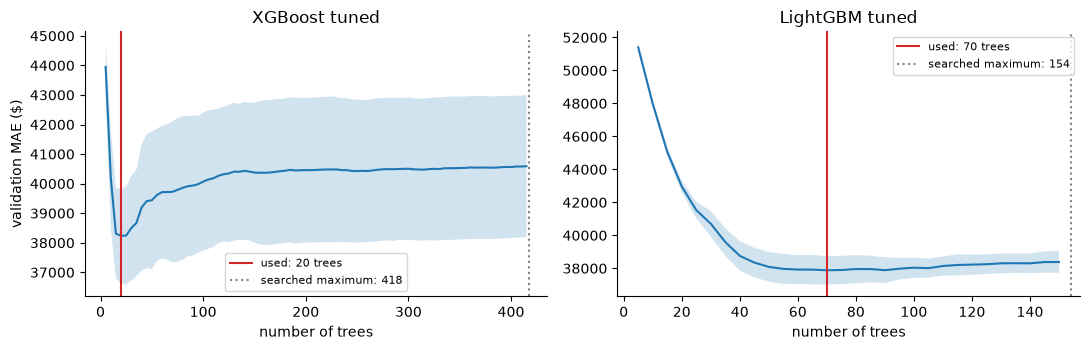

,trees used,within 1 sd of minimum,searched / baseline maximum
model,,,
xgb_baseline_log,160,160-160,500
xgb_log_tuned,20,15-75,418
lgbm_baseline_log,45,45-45,500
lgbm_log_tuned,70,45-150,154


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, curve, k, mx, title in [(axes[0], curve_x, k_x, max_x, "XGBoost tuned"), (axes[1], curve_l, k_l, max_l, "LightGBM tuned")]:
    ax.plot(curve["trees"], curve["val_MAE_mean"])
    ax.fill_between(curve["trees"], curve["val_MAE_mean"] - curve["val_MAE_sd"], curve["val_MAE_mean"] + curve["val_MAE_sd"], alpha=.2)
    ax.axvline(k, color="C3", label=f"used: {k} trees")
    ax.axvline(mx, color="grey", ls=":", label=f"searched maximum: {mx}")
    ax.set_title(title)
    ax.set_xlabel("number of trees")
    ax.legend(fontsize=8)
axes[0].set_ylabel("validation MAE ($)")
plt.tight_layout()
plt.show()
trees_table = pd.DataFrame({
    "model": ["xgb_baseline_log", "xgb_log_tuned", "lgbm_baseline_log", "lgbm_log_tuned"],
    "trees used": [k_xb, k_x, k_lb, k_l], "within 1 sd of minimum": [f"{lo_xb}-{hi_xb}", f"{lo_x}-{hi_x}", f"{lo_lb}-{hi_lb}", f"{lo_l}-{hi_l}"],
    "searched / baseline maximum": [500, max_x, 500, max_l]}).set_index("model")
display(trees_table)

## Results on the validation set (all 4 models, metrics in dollars)

This is where the four models are compared. The validation set has 18 properties, so a gap of a few thousand dollars is within noise. The validation set has also chosen the number of trees, so these numbers are optimistic. In the table, `searched_max_trees` is the maximum chosen by the search and `trees` is the number actually used.

In [8]:
results = pd.DataFrame(RESULTS).set_index("model")
display(results)

by_n = pd.concat({"XGBoost tuned": evaluate_by_n(val_df, y_val, tuned_x_pred).set_index("n_documented")["WAPE_%"],
                  "LightGBM tuned": evaluate_by_n(val_df, y_val, tuned_l_pred).set_index("n_documented")["WAPE_%"]}, axis=1).round(1)
by_n["validation rows"] = val_df["n_documented"].value_counts().sort_index()
by_n["validation properties"] = val_df.groupby("n_documented")["Property_ID"].nunique()
print("validation WAPE (%) by N, tuned models:")
display(by_n)

whole = np.isclose(val_df["sum_value"], val_df["true_total_value"])
print(f"validation rows where the basket is the whole home: {int(whole.sum())} of {len(val_df)} (diagnostic only)")
for name, p in [("xgb_log_tuned", tuned_x_pred), ("lgbm_log_tuned", tuned_l_pred)]:
    print(f"  {name}: MAE all rows ${mean_absolute_error(y_val, p):,.0f} | without whole-home rows ${mean_absolute_error(y_val[~whole], p[~whole]):,.0f}")

,val_MAE,val_WAPE_%,trees,search_val_MAE_logscale,searched_max_trees
model,,,,,
xgb_baseline_log,35671,47.4,160,NaN,NaN
xgb_log_tuned,37535,49.9,20,0.6240,418.0
lgbm_baseline_log,37191,49.4,45,NaN,NaN
lgbm_log_tuned,36793,48.9,70,0.6667,154.0


validation WAPE (%) by N, tuned models:


,XGBoost tuned,LightGBM tuned,validation rows,validation properties
n_documented,,,,
10,65.2,63.3,90,18
20,48.9,48.6,65,13
30,43.0,41.3,45,9
50,33.6,34.1,30,6


validation rows where the basket is the whole home: 20 of 230 (diagnostic only)
  xgb_log_tuned: MAE all rows $37,535 | without whole-home rows $39,147
  lgbm_log_tuned: MAE all rows $36,793 | without whole-home rows $38,179


## Final hyperparameters (the number of trees is the one chosen on validation)

In [9]:
import joblib
final_x = {**best_x, "n_estimators": k_x, "searched_max_trees": max_x}
final_l = {**best_l, "n_estimators": k_l, "searched_max_trees": max_l}
hyperparams_df = pd.DataFrame([{"model": "xgboost_log_tuned", **final_x}, {"model": "lightgbm_log_tuned", **final_l}])
joblib.dump({r["model"]: {k: (int(v) if isinstance(v, float) and v.is_integer() else v) for k, v in r.items() if k != "model" and pd.notna(v)} for r in hyperparams_df.to_dict("records")}, MODELS / "final_hyperparameters.joblib")   # the final hyperparameters, one dict per model (joblib only, no CSV)
display(hyperparams_df.set_index("model").T.dropna(how="all"))

model,xgboost_log_tuned,lightgbm_log_tuned
colsample_bytree,0.812542,0.788886
learning_rate,0.166784,0.044682
max_depth,6.000000,7.000000
min_child_weight,10.000000,NaN
n_estimators,20.000000,70.000000
reg_alpha,0.010000,0.100000
reg_lambda,5.000000,2.000000
subsample,0.885838,0.702427
searched_max_trees,418.000000,154.000000
min_child_samples,NaN,7.000000


## Save predictions (converted back to dollars, validation rows), models and results

In [10]:
def build_predictions_df(df, X, y, split_name):
    out = df[["Property_ID", "n_documented"]].copy()
    out["split"] = split_name
    out["true_total_value"] = np.asarray(y)
    out["xgb_tuned_pred"] = np.expm1(tuned_x.predict(X))
    out["lgbm_tuned_pred"] = np.expm1(tuned_l.predict(X))
    return out
all_preds = build_predictions_df(val_df, X_val, y_val, "val")          # validation rows only: the test set is not used in this notebook
all_preds.to_parquet(INTERIM / "tuned_model_predictions.parquet", index=False)
joblib.dump(tuned_x, MODELS / "xgb_log_model.joblib")
joblib.dump(tuned_l, MODELS / "lgbm_log_model.joblib")
print("saved predictions", all_preds.shape, "| 2 models | final_hyperparameters.joblib")

saved predictions (230, 6) | 2 models | final_hyperparameters.joblib


## Summary of the modelling results (numbers from the run above, the test set is not used)

- **Setup:** The final models are fitted on all of train (1,030 rows from 81 properties) with no early-stopping slice, and validation has 230 rows from 18 properties. The test set is never loaded, and the final models are scored on it once, in `05_ky_test_evaluation`. The target is on the log scale and the models use 26 features.
- **Search:** 80 random candidates per model were fitted on train and scored on validation. The best log-scale validation MAE is 0.6240 for XGBoost and 0.6667 for LightGBM.
- **Trees chosen on the validation curve (mean of 8 seeds):** The tuned XGBoost uses **20** trees (within one standard deviation of the minimum the range is 15 to 75, and the searched maximum is 418). The tuned LightGBM uses **70** trees (range 45 to 150, searched maximum 154). The baselines use 160 trees for XGBoost and 45 trees for LightGBM.
- **Validation results (dollars):** The table below summarises the four models.

| model | trees | validation MAE | validation WAPE |
|---|---|---|---|
| xgb_baseline_log | 160 | $35,671 | 47.4% |
| xgb_log_tuned | 20 | $37,535 | 49.9% |
| lgbm_baseline_log | 45 | $37,191 | 49.4% |
| lgbm_log_tuned | 70 | $36,793 | 48.9% |

- **Validation is used three times:** The search score, the number of trees and the model comparison all use it, so these numbers are optimistic and should not be read as the true error on new homes.
- **Tuning does not clearly help:** The tuned XGBoost ($37,535) is worse than its own baseline ($35,671), and the tuned LightGBM is only slightly better than its baseline ($36,793 against $37,191). With 18 validation properties these gaps are within noise.
- **By N:** The validation WAPE (%) for XGBoost and LightGBM is 65.2 and 63.3 at N = 10 (18 properties), 48.9 and 48.6 at N = 20 (13 properties), 43.0 and 41.3 at N = 30 (9 properties) and 33.6 and 34.1 at N = 50 (6 properties). The error falls steadily as N grows.
- **Whole-home baskets:** 20 of the 230 validation rows are baskets that equal the whole home. Without them the validation MAE rises to $39,147 for XGBoost and $38,179 for LightGBM.
- **Next step:** `04_ky_ensemble_and_intervals` sets the blend weight and the margins on `tuned_model_predictions.parquet` (validation rows), and `05_ky_test_evaluation` then scores the final models on the test set once.
- **Files:** `models/regression/` holds `xgb_log_model.joblib`, `lgbm_log_model.joblib` and `final_hyperparameters.joblib` (a dict with one entry per model; there is no CSV copy). `data/interim/regression/` holds `tuned_model_predictions.parquet` with the validation rows.